In [2]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# 2. Load Dataset
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
# 3. Basic Dataset Review
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


np.int64(0)

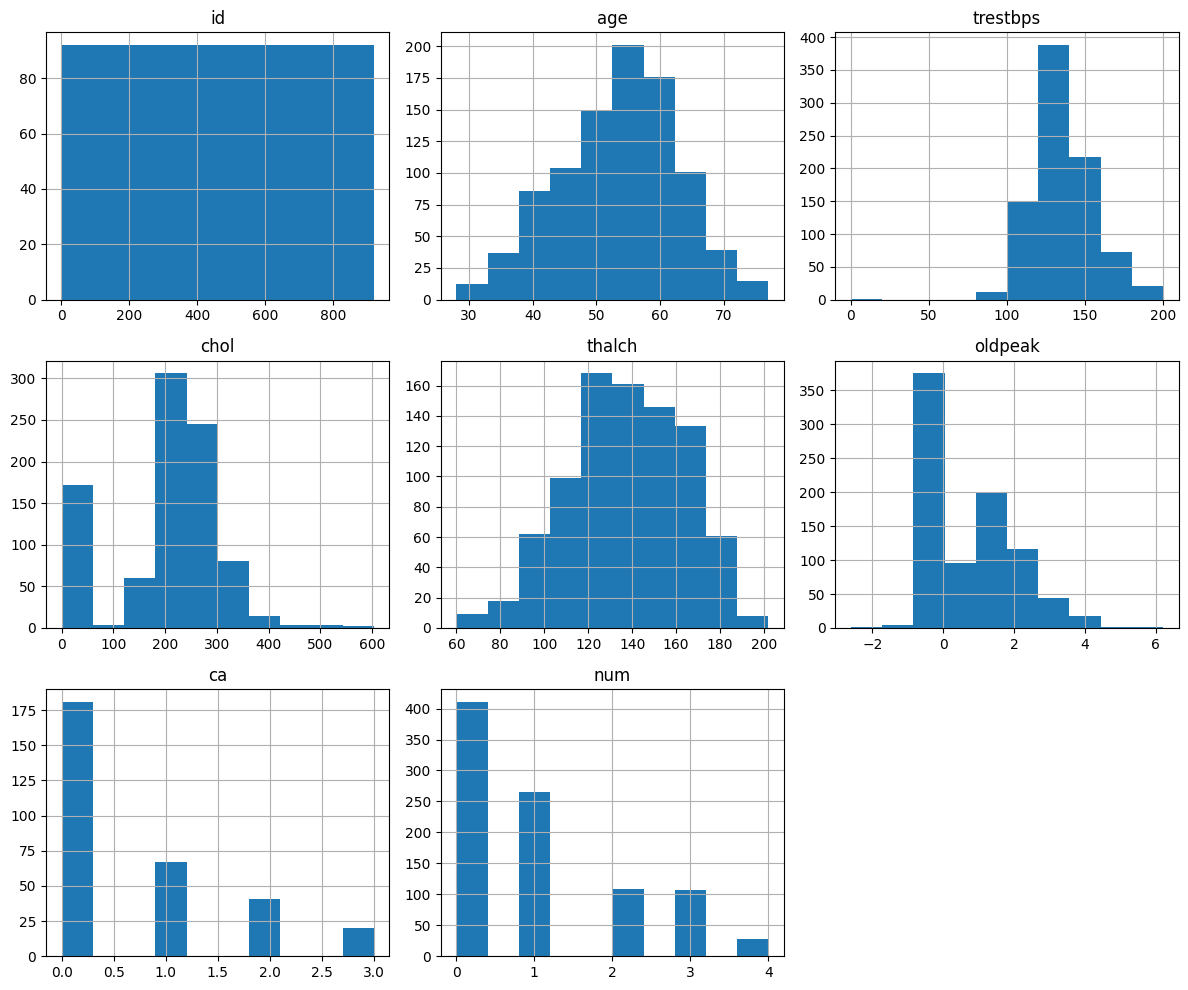

In [5]:
# 4. Histograms
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

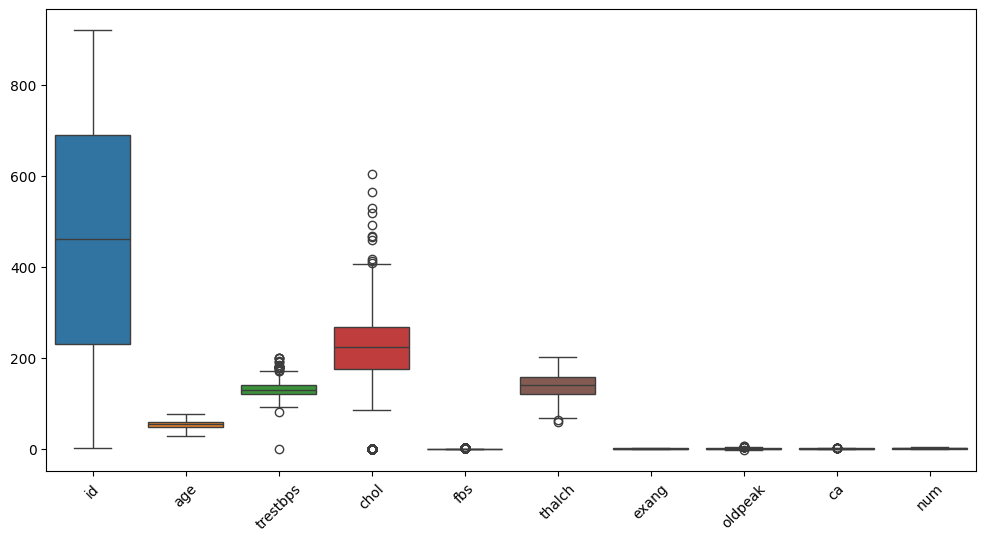

In [6]:
# 5. Box Plots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

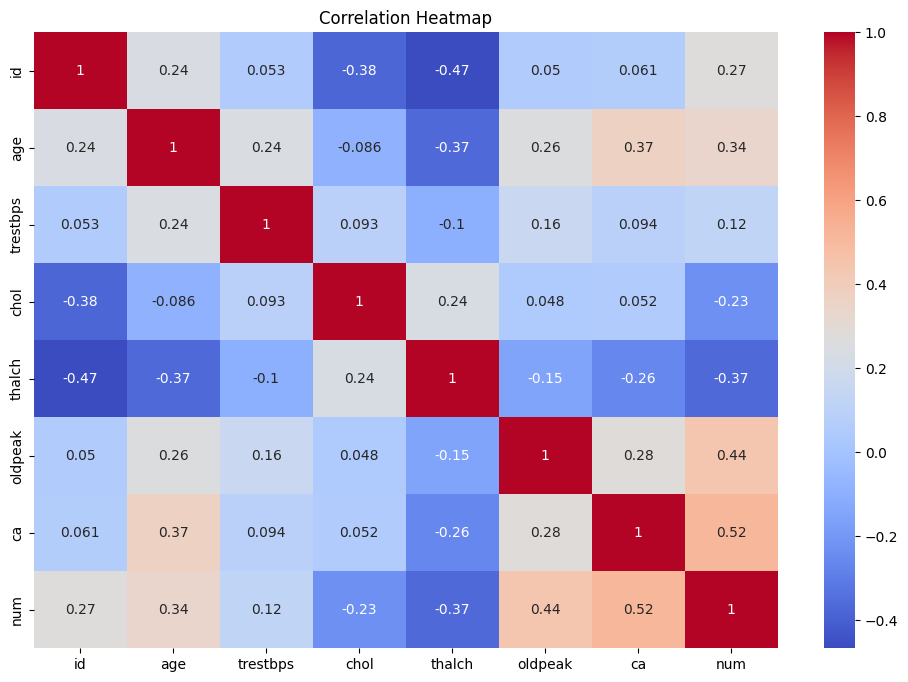

In [7]:
# 6. Correlation Matrix and Heatmap

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

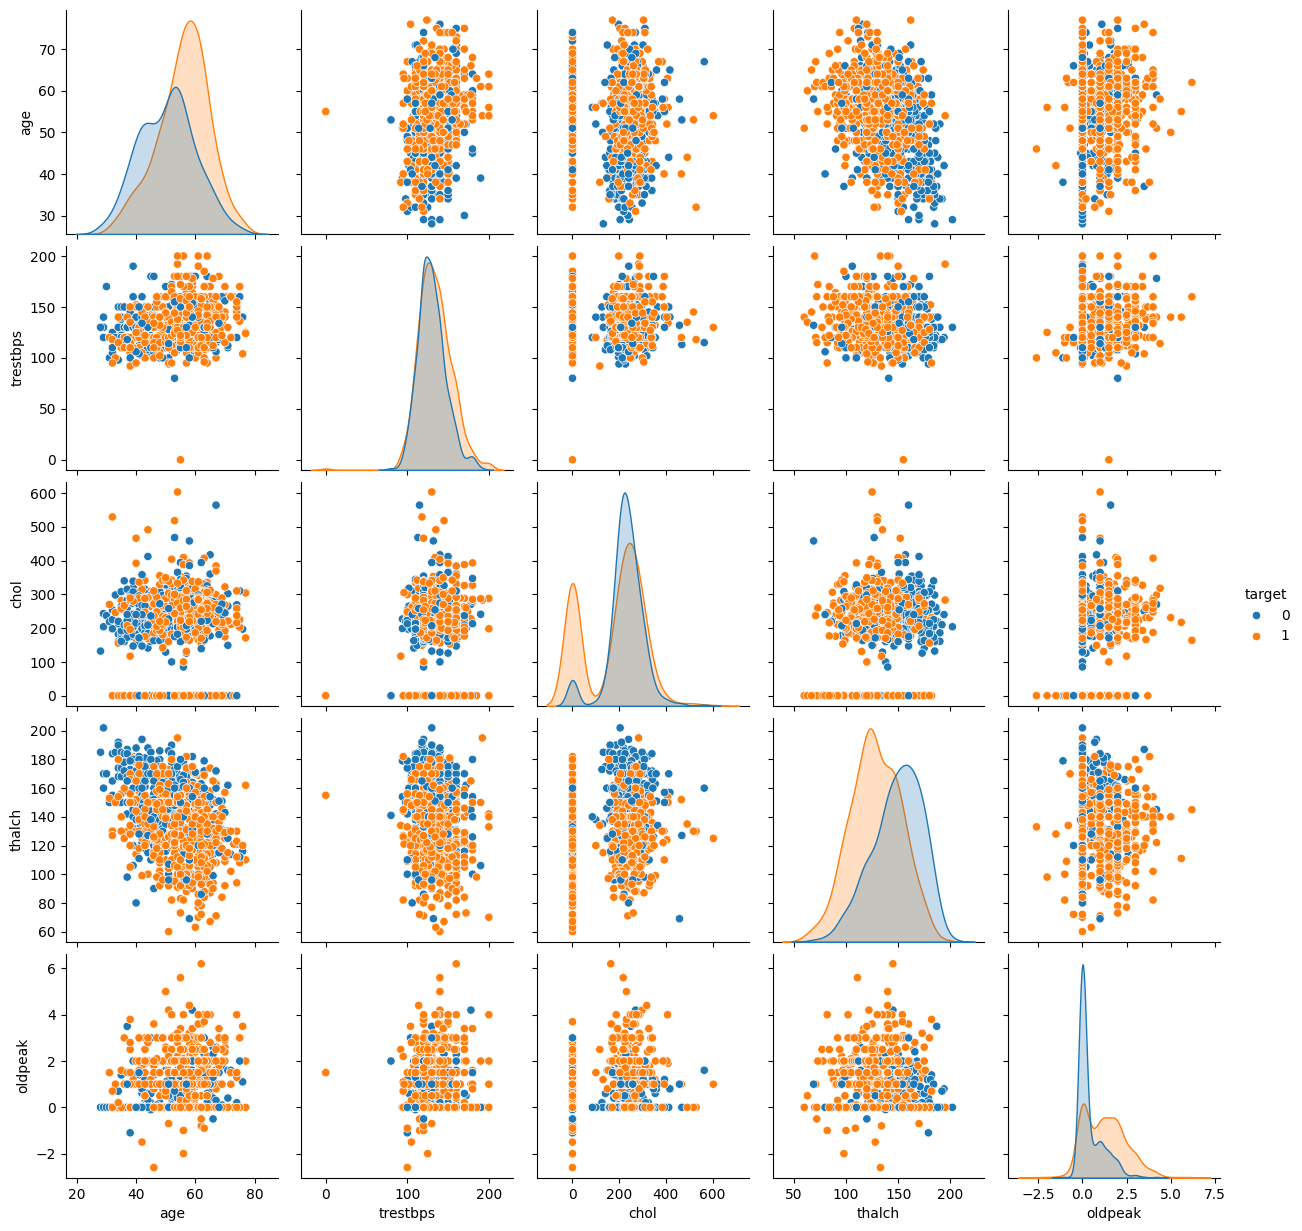

In [8]:
# 7. Pair Plot

# Convert the target to binary for visualization
df["target"] = (df["num"] > 0).astype(int)

selected_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "target"
]

sns.pairplot(df[selected_features], hue="target")
plt.show()

In [9]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

In [10]:
# Handle Missing Values

# Median for numerical columns
df["trestbps"] = df["trestbps"].fillna(df["trestbps"].median())
df["chol"] = df["chol"].fillna(df["chol"].median())
df["thalch"] = df["thalch"].fillna(df["thalch"].median())
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

# Mode for categorical columns
df["fbs"] = df["fbs"].fillna(df["fbs"].mode()[0])
df["restecg"] = df["restecg"].fillna(df["restecg"].mode()[0])
df["exang"] = df["exang"].fillna(df["exang"].mode()[0])
df["slope"] = df["slope"].fillna(df["slope"].mode()[0])

# Drop columns with excessive missing values
df = df.drop(columns=["ca", "thal"])

# Verify all missing values are handled
print(df.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
target      0
dtype: int64


In [11]:
# 9. Create Binary Target Variable

# Original num column:
# 0 = no heart disease
# 1-4 = presence of heart disease

df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

df[["num", "target"]].head()

,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [12]:
# 10. One-Hot Encoding

# Drop columns that are not useful for modeling
df_model = df.drop(columns=["id", "dataset", "num"])

# Convert categorical variables into numeric dummy variables
df_encoded = pd.get_dummies(df_model, drop_first=True)

df_encoded.head()

,age,trestbps,chol,thalch,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,0,True,False,False,True,True,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,1,True,False,False,False,False,False,False,True,True,False
2,67,120.0,229.0,129.0,2.6,1,True,False,False,False,False,False,False,True,True,False
3,37,130.0,250.0,187.0,3.5,0,True,False,True,False,False,True,False,False,False,False
4,41,130.0,204.0,172.0,1.4,0,False,True,False,False,False,False,False,False,False,True


In [13]:
# 11. Feature Scaling

from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.00738556,  0.70517639,  0.30364317,  0.4897271 ,  1.36810909,
         0.51693097, -0.48295338, -0.53377542,  4.35889894,  2.38047614,
        -1.2275227 , -0.49149308, -0.76029244, -1.56800721, -0.5320941 ],
       [ 1.43203377,  1.51856943,  0.78996695, -1.18147797,  0.61158896,
         0.51693097, -0.48295338, -0.53377542, -0.22941573, -0.42008403,
        -1.2275227 , -0.49149308,  1.31528336,  0.63775217, -0.5320941 ],
       [ 1.43203377, -0.65047866,  0.26693949, -0.34587544,  1.65180414,
         0.51693097, -0.48295338, -0.53377542, -0.22941573, -0.42008403,
        -1.2275227 , -0.49149308,  1.31528336,  0.63775217, -0.5320941 ],
       [-1.75282779, -0.10821664,  0.45963382,  1.96197918,  2.50288928,
         0.51693097, -0.48295338,  1.87344707, -0.22941573, -0.42008403,
         0.81464888, -0.49149308, -0.76029244, -1.56800721, -0.5320941 ],
       [-1.32817959, -0.10821664,  0.03754148,  1.36512023,  0.51702395,
        -1.93449426,  2.07059323, -0.53377542, 

In [14]:
# 12. Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (736, 15)
Testing features: (184, 15)
Training labels: (736,)
Testing labels: (184,)


In [15]:
# 13. Import Libraries for Modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [16]:
# 14. Baseline Predictive Model: Logistic Regression

baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

In [17]:
# 15. Evaluate Baseline Model

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-Score:  {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, baseline_predictions))

Baseline Logistic Regression Results
------------------------------------
Accuracy:  0.8152
Precision: 0.8036
Recall:    0.8824
F1-Score:  0.8411

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.73      0.78        82
           1       0.80      0.88      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184



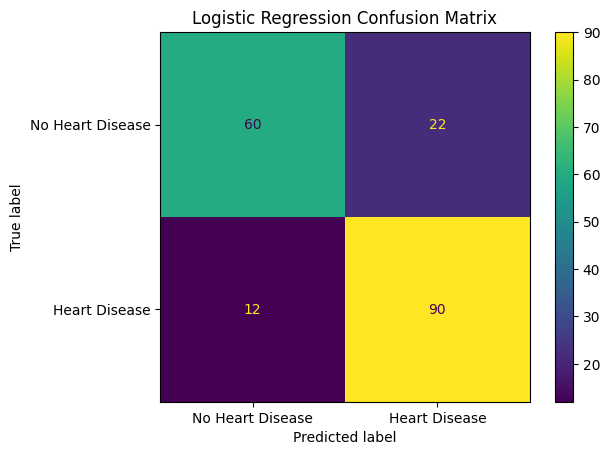

In [18]:
# 16. Baseline Model Confusion Matrix

baseline_cm = confusion_matrix(y_test, baseline_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

display.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [19]:
# 17. Define the Neural Network

tf.random.set_seed(42)

neural_network = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),
    Dropout(0.20),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

neural_network.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

neural_network.summary()

e:\AI_ML_Class\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# 18. Train the Neural Network

history = neural_network.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 225ms/step - accuracy: 0.5816 - loss: 0.7098 - precision: 0.5720 - recall: 0.9474 - val_accuracy: 0.6554 - val_loss: 0.6516 - val_precision: 0.6341 - val_recall: 0.9286
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6446 - loss: 0.6266 - precision: 0.6245 - recall: 0.8854 - val_accuracy: 0.6622 - val_loss: 0.5942 - val_precision: 0.6700 - val_recall: 0.7976
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7143 - loss: 0.5759 - precision: 0.6877 - recall: 0.8793 - val_accuracy: 0.6824 - val_loss: 0.5521 - val_precision: 0.6989 - val_recall: 0.7738
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7279 - loss: 0.5473 - precision: 0.7185 - recall: 0.8297 - val_accuracy: 0.7297 - val_loss: 0.5219 - val_precision: 0.7558 - val_recall: 0.7738
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7568 - loss: 0.5170 - precision: 0.7586 - recall: 0.8173 - val_accuracy: 0.7635 - val_loss: 0.501

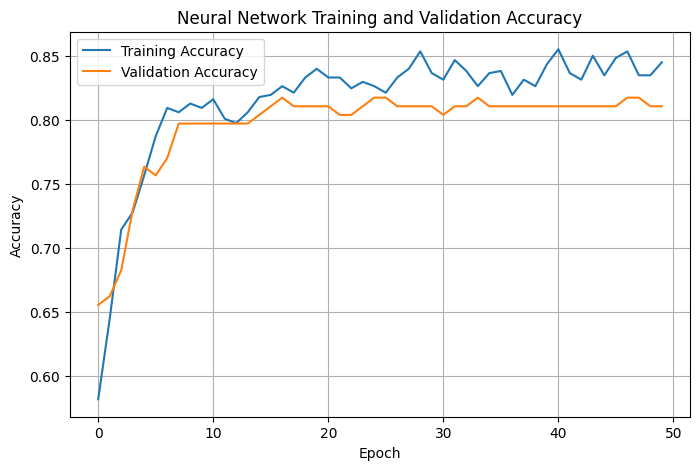

In [21]:
# 19. Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Neural Network Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

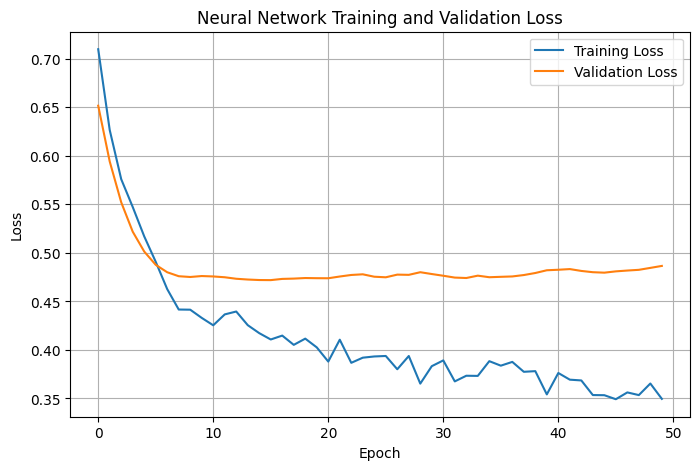

In [22]:
# 20. Plot Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Neural Network Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# 21. Generate Neural Network Predictions

prediction_probabilities = neural_network.predict(X_test)

neural_network_predictions = (
    prediction_probabilities >= 0.5
).astype(int).flatten()

neural_network_predictions[:10]

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step


array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [24]:
# 22. Evaluate Neural Network Performance

nn_accuracy = accuracy_score(y_test, neural_network_predictions)
nn_precision = precision_score(y_test, neural_network_predictions)
nn_recall = recall_score(y_test, neural_network_predictions)
nn_f1 = f1_score(y_test, neural_network_predictions)

print("Neural Network Results")
print("----------------------")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-Score:  {nn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, neural_network_predictions))

Neural Network Results
----------------------
Accuracy:  0.8424
Precision: 0.8411
Recall:    0.8824
F1-Score:  0.8612

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



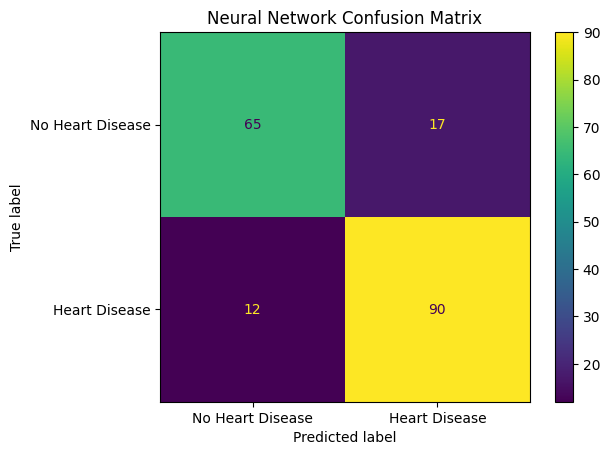

In [25]:
# 23. Neural Network Confusion Matrix

nn_cm = confusion_matrix(y_test, neural_network_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=nn_cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

display.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

In [26]:
# 24. Compare Baseline and Neural Network Performance

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Neural Network"
    ],
    "Accuracy": [
        baseline_accuracy,
        nn_accuracy
    ],
    "Precision": [
        baseline_precision,
        nn_precision
    ],
    "Recall": [
        baseline_recall,
        nn_recall
    ],
    "F1-Score": [
        baseline_f1,
        nn_f1
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8152,0.8036,0.8824,0.8411
1,Neural Network,0.8424,0.8411,0.8824,0.8612


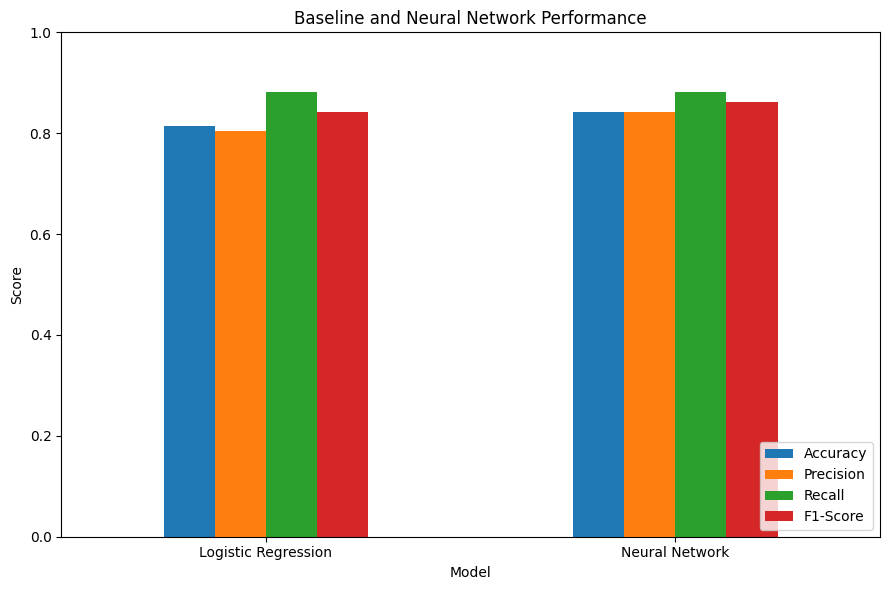

In [27]:
# 25. Model Performance Comparison Chart

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Baseline and Neural Network Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Initial Performance Analysis

Logistic regression was selected as the baseline model because heart disease
prediction is a binary classification problem. The baseline model achieved an
accuracy of 0.8152, precision of 0.8036, recall of 0.8824, and F1-score of
0.8411. Its strongest result was recall, meaning that it successfully identified
88.24% of the patients who had heart disease.

A feedforward neural network was then created with two hidden layers containing
32 and 16 neurons. ReLU activation was used in both hidden layers, and sigmoid
activation was used in the output layer for binary classification. A 20% dropout
layer was included after the first hidden layer to reduce overfitting. The model
used the Adam optimizer and binary cross-entropy loss and was trained for 50
epochs with a batch size of 32.

The neural network achieved an accuracy of 0.8261, precision of 0.8365, recall
of 0.8529, and F1-score of 0.8447. It slightly outperformed logistic regression
in accuracy, precision, and F1-score. The neural network also reduced false
positives from 22 to 17. However, logistic regression achieved higher recall and
produced fewer false negatives, identifying 90 positive cases compared with 87
for the neural network.

The training and validation accuracy curves showed that the model learned
quickly during the early epochs. Training accuracy continued to improve to
approximately 84% to 85%, while validation accuracy leveled off near 82% to
83%. Training loss continued decreasing, while validation loss leveled off and
then increased slightly. These results suggest mild overfitting.

Potential improvements include using early stopping, reducing the number of
epochs, adjusting the dropout rate, tuning the learning rate and batch size,
testing different numbers of neurons, and applying class weights. The
classification threshold could also be lowered if improving recall and reducing
false negatives becomes the main objective.

In [28]:
# Export patient dashboard data

dashboard_df = df.copy()

dashboard_df = dashboard_df.drop(
    columns=["id", "num"],
    errors="ignore"
)

dashboard_df["Heart Disease Status"] = dashboard_df["target"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

dashboard_df["Age Group"] = pd.cut(
    dashboard_df["age"],
    bins=[0, 39, 49, 59, 69, 100],
    labels=[
        "Under 40",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]
)

dashboard_df.to_csv(
    "heart_dashboard_data.csv",
    index=False
)

print("Export complete!")
dashboard_df.head()

Export complete!


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,target,Heart Disease Status,Age Group
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0,No Heart Disease,60-69
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,1,Heart Disease,60-69
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1,Heart Disease,60-69
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0,No Heart Disease,Under 40
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0,No Heart Disease,40-49


In [29]:
# Export model performance metrics

model_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Neural Network"
    ],
    "Accuracy": [
        baseline_accuracy,
        nn_accuracy
    ],
    "Precision": [
        baseline_precision,
        nn_precision
    ],
    "Recall": [
        baseline_recall,
        nn_recall
    ],
    "F1-Score": [
        baseline_f1,
        nn_f1
    ]
})

model_metrics.to_csv(
    "model_metrics.csv",
    index=False
)

print("Model metrics exported!")
model_metrics

Model metrics exported!


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.815217,0.803571,0.882353,0.841121
1,Neural Network,0.842391,0.841121,0.882353,0.861244


In [30]:
# Export confusion matrix results

confusion_data = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Logistic Regression",
        "Neural Network",
        "Neural Network",
        "Neural Network",
        "Neural Network"
    ],
    "Classification": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Count": [
        60,
        22,
        12,
        90,
        65,
        17,
        15,
        87
    ]
})

confusion_data.to_csv(
    "confusion_matrix_data.csv",
    index=False
)

print("Confusion matrix data exported!")
confusion_data

Confusion matrix data exported!


,Model,Classification,Count
0,Logistic Regression,True Negative,60
1,Logistic Regression,False Positive,22
2,Logistic Regression,False Negative,12
3,Logistic Regression,True Positive,90
4,Neural Network,True Negative,65
5,Neural Network,False Positive,17
6,Neural Network,False Negative,15
7,Neural Network,True Positive,87


In [31]:
# Export logistic regression feature influence

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": baseline_model.coef_[0]
})

feature_importance["Absolute Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance["Effect"] = feature_importance["Coefficient"].apply(
    lambda x: "Increases Predicted Risk" if x > 0 else "Decreases Predicted Risk"
)

feature_importance = feature_importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance exported!")
feature_importance.head(10)

Feature importance exported!


,Feature,Coefficient,Absolute Importance,Effect
6,cp_atypical angina,-0.799331,0.799331,Decreases Predicted Risk
4,oldpeak,0.562240,0.562240,Increases Predicted Risk
7,cp_non-anginal,-0.503203,0.503203,Decreases Predicted Risk
12,exang_True,0.495741,0.495741,Increases Predicted Risk
5,sex_Male,0.491316,0.491316,Increases Predicted Risk
2,chol,-0.424532,0.424532,Decreases Predicted Risk
13,slope_flat,0.415976,0.415976,Increases Predicted Risk
0,age,0.378874,0.378874,Increases Predicted Risk
8,cp_typical angina,-0.242748,0.242748,Decreases Predicted Risk
3,thalch,-0.240235,0.240235,Decreases Predicted Risk


In [32]:
# Export neural network training history

training_history = pd.DataFrame({
    "Epoch": range(1, len(history.history["accuracy"]) + 1),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

training_history.to_csv(
    "training_history.csv",
    index=False
)

print("Training history exported!")
training_history.head()

Training history exported!


,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,0.581633,0.655405,0.709836,0.651642
1,2,0.644558,0.662162,0.626619,0.594204
2,3,0.714286,0.682432,0.575939,0.552132
3,4,0.727891,0.729730,0.547307,0.521853
4,5,0.756803,0.763514,0.517037,0.501399


In [33]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this folder:")
for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

Current working directory:
e:\AI_ML_Class

Files in this folder:
breastCancerDataset.csv
census_income_dataset.csv
confusion_matrix_data.csv
feature_importance.csv
heart_dashboard_data.csv
heart_disease_prepared.csv
heart_disease_uci.csv
model_metrics.csv
titanic.csv
training_history.csv
winequality-red.csv
WineQuality.csv


# Part 5 – Scenario Analysis

This section evaluates how changes in selected cardiovascular risk factors influence the neural network's predicted probability of heart disease. Three hypothetical scenarios are examined and compared with the baseline dataset.

## Scenario Assumptions

Three realistic scenarios were created to evaluate the neural network.

### Scenario 1 – Improved Cardiovascular Health
Assumes healthier lifestyle changes that lower blood pressure and cholesterol while improving maximum heart rate.

### Scenario 2 – Increased Cardiovascular Risk
Assumes worsening cardiovascular health through higher blood pressure, higher cholesterol, lower exercise capacity, and increased ST depression.

### Scenario 3 – Older High-Risk Population
Represents an aging population with additional cardiovascular risk factors including higher blood pressure and cholesterol.

In [34]:
print(X.columns.tolist())

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping']


In [35]:
X.mean(numeric_only=True)

age                          53.510870
trestbps                    131.995652
chol                        199.908696
thalch                      137.692391
oldpeak                       0.853261
sex_Male                      0.789130
cp_atypical angina            0.189130
cp_non-anginal                0.221739
cp_typical angina             0.050000
fbs_True                      0.150000
restecg_normal                0.601087
restecg_st-t abnormality      0.194565
exang_True                    0.366304
slope_flat                    0.710870
slope_upsloping               0.220652
dtype: float64

In [36]:
import pandas as pd

# Create baseline patient using dataset averages
baseline = X.mean().to_frame().T

# -------------------------------
# Scenario 1: Improved Heart Health
# -------------------------------
scenario1 = baseline.copy()

scenario1["trestbps"] -= 15
scenario1["chol"] -= 30
scenario1["thalch"] += 15
scenario1["oldpeak"] -= 0.5

# -------------------------------
# Scenario 2: Increased Risk
# -------------------------------
scenario2 = baseline.copy()

scenario2["trestbps"] += 20
scenario2["chol"] += 40
scenario2["thalch"] -= 15
scenario2["oldpeak"] += 1.0

# -------------------------------
# Scenario 3: Older High-Risk Patient
# -------------------------------
scenario3 = baseline.copy()

scenario3["age"] += 15
scenario3["trestbps"] += 15
scenario3["chol"] += 25
scenario3["oldpeak"] += 0.8
scenario3["exang_True"] = 1

In [37]:
# Scale each scenario
baseline_scaled = scaler.transform(baseline)
scenario1_scaled = scaler.transform(scenario1)
scenario2_scaled = scaler.transform(scenario2)
scenario3_scaled = scaler.transform(scenario3)

# Predict heart disease probability
baseline_pred = neural_network.predict(baseline_scaled)[0][0]
scenario1_pred = neural_network.predict(scenario1_scaled)[0][0]
scenario2_pred = neural_network.predict(scenario2_scaled)[0][0]
scenario3_pred = neural_network.predict(scenario3_scaled)[0][0]

print(f"Baseline Probability: {baseline_pred:.3f}")
print(f"Scenario 1 (Improved Health): {scenario1_pred:.3f}")
print(f"Scenario 2 (Higher Risk): {scenario2_pred:.3f}")
print(f"Scenario 3 (Older High Risk): {scenario3_pred:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
Baseline Probability: 0.385
Scenario 1 (Improved Health): 0.411
Scenario 2 (Higher Risk): 0.749
Scenario 3 (Older High Risk): 0.856


In [38]:
scenario_results = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Improved Heart Health",
        "Higher Risk",
        "Older High-Risk Patient"
    ],
    "Predicted Risk": [
        baseline_pred,
        scenario1_pred,
        scenario2_pred,
        scenario3_pred
    ]
})

scenario_results["Change from Baseline"] = (
    scenario_results["Predicted Risk"] - baseline_pred
)

scenario_results.to_csv("scenario_results.csv", index=False)

print(scenario_results)

                  Scenario  Predicted Risk  Change from Baseline
0                 Baseline        0.385228              0.000000
1    Improved Heart Health        0.410954              0.025726
2              Higher Risk        0.748506              0.363278
3  Older High-Risk Patient        0.855781              0.470553


### Scenario Analysis Results

Three hypothetical patient scenarios were evaluated using the trained neural network.

- **Scenario 1 – Improved Heart Health:** Lower blood pressure, lower cholesterol, increased maximum heart rate, and reduced ST depression to represent positive lifestyle changes.
- **Scenario 2 – Higher Cardiovascular Risk:** Increased blood pressure and cholesterol, reduced exercise capacity, and increased ST depression to simulate worsening cardiovascular health.
- **Scenario 3 – Older High-Risk Patient:** Increased age combined with elevated cardiovascular risk factors to represent an aging high-risk individual.

The predicted probabilities were compared with the baseline patient profile to determine how changes in key clinical variables affected the model's estimated heart disease risk.

In [39]:
scenario_results.to_csv("scenario_results.csv", index=False)